#  Extraction of Respiration Signal from ECG & Breathing Rate Estimation

---

##  Objective

The goal of this project is to:

- Extract the **respiration (breathing) signal** from an ECG signal  
- Remove noise using appropriate **signal processing techniques**  
- Calculate the **breathing rate (breaths per minute)**  

---

## Dataset Information

- Dataset: **MIT-BIH Arrhythmia Database (Record 102)**
- File types: `.dat`, `.hea`, `.atr`
- Sampling Frequency:

>  **fs = 360 Hz**

---

## Methodology

### 🔹 Step 1: Load ECG Signal

- ECG signal is loaded using the `wfdb` library
- First channel (MLII) is used

[
t = \frac{n}{f_s}
]

---

### 🔹 Step 2: R-Peak Detection

- R-peaks represent heartbeats
- Detected using `find_peaks`

> Important parameter:
- Minimum distance between peaks = `0.6 × fs`

✔ Ensures only valid heartbeats are detected  
✔ Avoids false detections  

---

### 🔹 Step 3: ECG-Derived Respiration (EDR)

Respiration is **not directly present** in ECG.

 It is extracted using:

>  **Amplitude Modulation of R-peaks**

Steps:
1. Extract R-peak amplitudes  
2. Interpolate them using cubic interpolation  

\[
r(t) = \text{interp1d}(t_{peaks}, A_{peaks})
\]

✔ This creates a smooth **respiratory envelope signal**

---

##  Step 4: Filtering (MOST IMPORTANT)

###  Filter Used:
>  **4th Order Butterworth Low-Pass Filter**

### Cutoff Frequency:
\[
f_c = 0.5 \, \text{Hz}
\]

---

## Why This Filter?

### 🔹 Key Insight:
- Respiration frequency range:
\[
0.1 \text{ Hz} \leq f \leq 0.5 \text{ Hz}
\]

### 🔹 Problems in signal:
- High-frequency noise  
- Cardiac artifacts  

---

### Why Butterworth?

- ✔ **Smooth output (no ripples)**
- ✔ **Preserves signal shape**
- ✔ **Best for biomedical signals**

---

### Why Low-Pass Filter?

- Removes unwanted **high-frequency components**
- Keeps only **respiration band (≤ 0.5 Hz)**

---

## Mathematical Model of Filter

### 🔹 Transfer Function:

\[
H(s) = \frac{\omega_c^2}{s^2 + \sqrt{2}\omega_c s + \omega_c^2}
\]

Where:
\[
\omega_c = 2\pi f_c
\]

---

### Differential Equation:

\[
\frac{d^2 y(t)}{dt^2} + \sqrt{2}\omega_c \frac{dy(t)}{dt} + \omega_c^2 y(t) = \omega_c^2 x(t)
\]

---

### Meaning:

- \(x(t)\): Input signal (interpolated envelope)  
- \(y(t)\): Output signal (respiration signal)  

> This equation defines how the filter smooths and removes noise

---

## Frequency Domain Analysis (FFT)

- FFT is used to analyze frequency content

### Observations:

- ECG dominant frequency ≈ **1–2 Hz (heart rate)**
- Respiration frequency ≈ **0.1–0.5 Hz**

> This validates our filter choice

---

## Breathing Rate Calculation

### Method Used:
> **Peak Detection on Filtered Signal**

---

### Steps:

1. Detect peaks in respiration signal  
2. Calculate time intervals between peaks  

\[
T_i = t_{i+1} - t_i
\]

3. Average interval:

\[
T_{avg} = \frac{1}{N} \sum T_i
\]

4. Breathing rate:

\[
\text{Breathing Rate} = \frac{60}{T_{avg}}
\]

---
## Results

- ✔ Clear respiration waveform obtained  
- ✔ Peaks correspond to breathing cycles  

> **Final Breathing Rate: ~ (17.45) breaths/min**

---

## Conclusion

- ECG can be used to **indirectly estimate respiration**
- Butterworth low-pass filter effectively removes noise
- Peak detection provides **accurate and simple breathing rate estimation**
---

## Summary

| Step | Method |
|------|--------|
| Signal Extraction | R-Peak Detection |
| Respiration Extraction | Interpolation (EDR) |
| Filtering | Butterworth Low-Pass |
| Rate Calculation | Peak Detection |

---

In [ ]:
!pip install wfdb

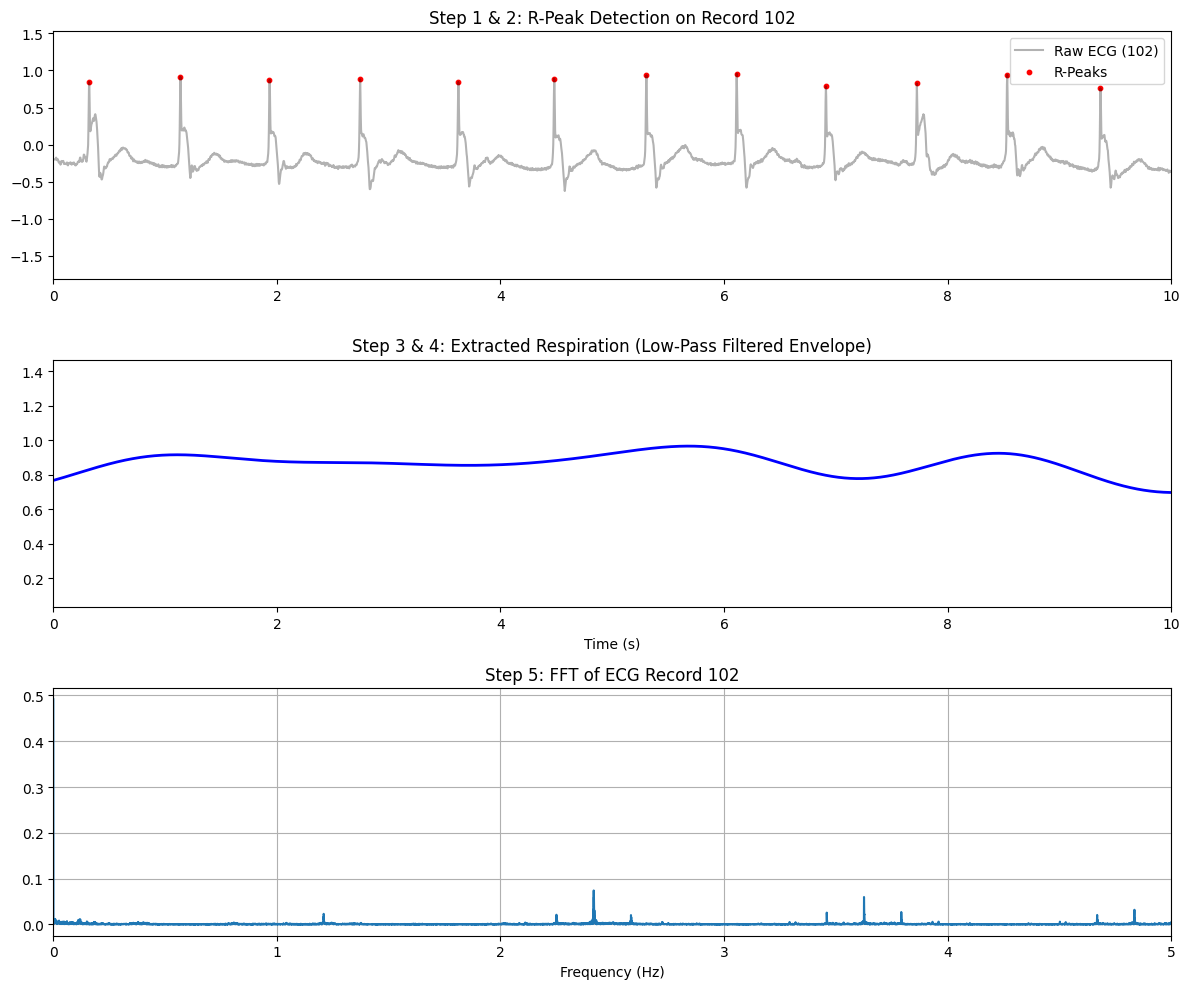

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.interpolate import interp1d

# --- 1. Load the MIT-BIH Record ---

record = wfdb.rdrecord('102')
signal = record.p_signal[:, 0]  # Take the first channel (usually MLII)
fs = record.fs                 # Sampling frequency from the .hea file
t = np.arange(len(signal)) / fs

# --- 2. R-Peak Detection ---
# Note: For real ECG, we use a height threshold or wfdb's built-in detectors.
# Here we use find_peaks on the raw signal for simplicity.
peaks, _ = find_peaks(signal, distance=fs*0.6, height=0.5)
peak_times = t[peaks]
peak_amplitudes = signal[peaks]

# --- 3. Extract Respiratory Envelope (Interpolation) ---
# The heart rate modulates the R-peak amplitude. We "connect the dots."
interp_func = interp1d(peak_times, peak_amplitudes, kind='cubic', fill_value="extrapolate")
respiration_raw = interp_func(t)

# --- 4. Low-Pass Filter (Isolate 0.1 - 0.5 Hz) ---
def lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# The EDR (ECG-Derived Respiration) signal
edr_signal = lowpass_filter(respiration_raw, cutoff=0.5, fs=fs)

# --- 5. Visualization ---
plt.figure(figsize=(12, 10))

# Subplot 1: Raw ECG with Detected Peaks
plt.subplot(3, 1, 1)
plt.plot(t, signal, color='black', alpha=0.3, label='Raw ECG (102)')
plt.scatter(peak_times, peak_amplitudes, color='red', s=10, label='R-Peaks')
plt.title("Step 1 & 2: R-Peak Detection on Record 102")
plt.xlim(0, 10)  # Show first 10 seconds
plt.legend()

# Subplot 2: Extracted Respiration (EDR)
plt.subplot(3, 1, 2)
plt.plot(t, edr_signal, color='blue', linewidth=2)
plt.title("Step 3 & 4: Extracted Respiration (Low-Pass Filtered Envelope)")
plt.xlabel("Time (s)")
plt.xlim(0, 10)

# Subplot 3: Frequency Domain (FFT)
plt.subplot(3, 1, 3)
n = len(signal)
freqs = np.fft.fftfreq(n, 1/fs)
fft_vals = np.abs(np.fft.fft(signal)) * 2 / n
plt.plot(freqs[:n//2], fft_vals[:n//2])
plt.title("Step 5: FFT of ECG Record 102")
plt.xlabel("Frequency (Hz)")
plt.xlim(0, 5) # Focus on heart rate and respiratory range
plt.grid(True)

plt.tight_layout()
plt.show()

Total breaths detected: 525
Average Breathing Rate: 17.45 BPM


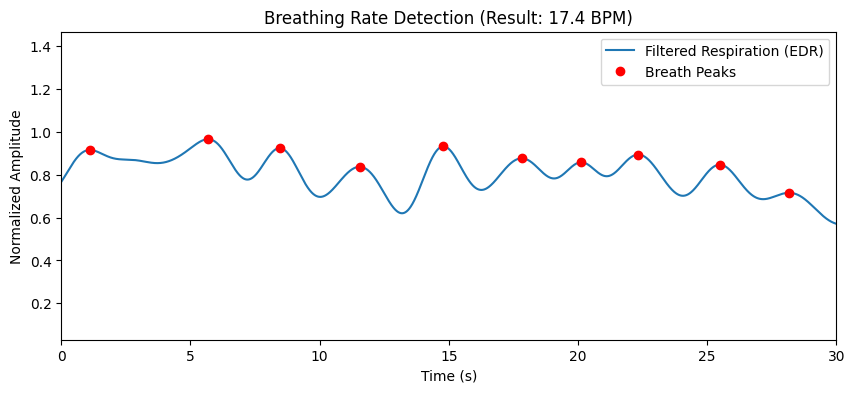

In [ ]:
# --- 6. Calculate Breathing Rate ---

# Find peaks of the filtered respiration signal
# We set a distance to avoid double-counting noisy peaks
# (e.g., max breathing rate of 30 bpm = 1 breath every 2 seconds)
resp_peaks, _ = find_peaks(edr_signal, distance=fs*2)

if len(resp_peaks) > 1:
    # Calculate intervals between peaks in seconds
    breath_intervals = np.diff(t[resp_peaks])

    # Calculate average interval
    avg_interval = np.mean(breath_intervals)

    # Convert to Breaths Per Minute (BPM)
    breathing_rate_bpm = 60 / avg_interval

    print(f"Total breaths detected: {len(resp_peaks)}")
    print(f"Average Breathing Rate: {breathing_rate_bpm:.2f} BPM")
else:
    print("Not enough respiratory cycles detected to calculate rate.")

# --- 7. Visualization of Breathing Peaks ---
plt.figure(figsize=(10, 4))
plt.plot(t, edr_signal, label='Filtered Respiration (EDR)')
plt.plot(t[resp_peaks], edr_signal[resp_peaks], "ro", label='Breath Peaks')
plt.title(f"Breathing Rate Detection (Result: {breathing_rate_bpm:.1f} BPM)")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.xlim(0, 30) # View a larger window to see multiple breaths
plt.show()